In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 [==============================] - 48s 0us/step


In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(train_images)

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # Using softmax here
])

In [5]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # Correct match
              metrics=['accuracy'])

In [6]:
history = model.fit(datagen.flow(train_images, train_labels, batch_size=64),
                    epochs=30,
                    validation_data=(test_images, test_labels))

Epoch 1/30


782/782 [==============================] - 44s 54ms/step - loss: 1.7214 - accuracy: 0.0973 - val_loss: 1.2458 - val_accuracy: 0.0688
Epoch 2/30
782/782 [==============================] - 37s 47ms/step - loss: 1.3387 - accuracy: 0.0982 - val_loss: 1.1308 - val_accuracy: 0.0799
Epoch 3/30
782/782 [==============================] - 43s 54ms/step - loss: 1.2037 - accuracy: 0.0993 - val_loss: 1.2844 - val_accuracy: 0.0855
Epoch 4/30
782/782 [==============================] - 38s 49ms/step - loss: 1.1123 - accuracy: 0.0995 - val_loss: 0.9458 - val_accuracy: 0.1063
Epoch 5/30
782/782 [==============================] - 39s 50ms/step - loss: 1.0571 - accuracy: 0.0998 - val_loss: 1.1691 - val_accuracy: 0.0595
Epoch 6/30
782/782 [==============================] - 43s 55ms/step - loss: 1.0078 - accuracy: 0.1008 - val_loss: 1.1238 - val_accuracy: 0.0380
Epoch 7/30
782/782 [==============================] - 45s 58ms/step - loss: 0.9676 - accuracy: 0.1001 - val_loss: 0.9346 - val_accurac

In [7]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 2s - loss: 0.6425 - accuracy: 0.1018 - 2s/epoch - 6ms/step
Test accuracy: 0.10180000215768814


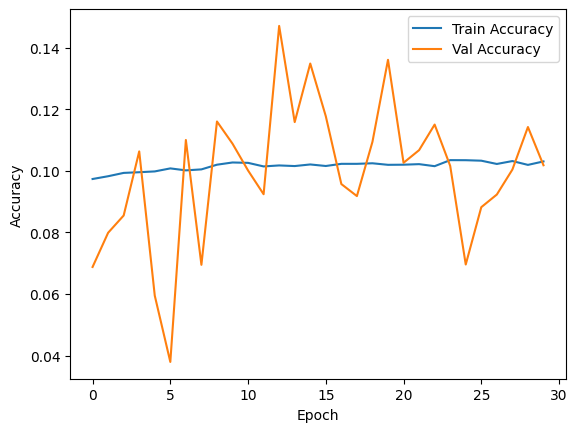

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(32, 32))  # Resize to CIFAR-10 size
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions)

    print(f"Predicted Class: {predicted_class} (Confidence: {confidence:.2f})")


In [10]:
image_path = "airplane.webp"

try:
    predict_image(image_path)
except FileNotFoundError:
    print(f"Error: File not found at {image_path}")
except Exception as e:
    print(f"An error occurred: {e}")

1/1 [==============================] - 0s 156ms/step
Predicted Class: airplane (Confidence: 0.99)
